## Project Title: Traffic Accident Risk Prediction (TARP)

**Unit:** SIT782  
**Prepared by:** Burhanuddin Ujjainwala  
**Project Team:** Suba (225094537), Burhanuddin (224802775), Khalid (224696667)  
**Task:** Importing, exploration and Exploratory Data Analysis of Melbourne Weather Data

## Dataset source

Official dataset: **Bureau of Meteorology data** from the Bureau of Meteorology data portal.

Historical dataset: **Historical data** from the Weatherzone data portal.

For this notebook, we are using the **weather** dataset, which contains records such as minimum temperature, maximum temperature, rainfall, Direction of maximum wind, Speed of maximum wind gust, temperature and humidity of day at different time, and much more.

## Weather dataset imported
Importing main libraries and loads each source file separately. Next, we checks the shape and structure of each imported dataset.

In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

data_dir = Path("D:/Project/MOP-Code/Playground/BurhanT12026")

hist_1516 = pd.read_csv(data_dir / "raw_data/Weather_Observation_2015_2016 part 2.csv",
                        delimiter=",", encoding="ISO-8859-1", header=4)

feb_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_February_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
mar_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_March_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
apr_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_April_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
may_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_May_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
jun_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_June_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
jul_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_July_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
aug_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_August_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
sep_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_September_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
oct_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_October_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
nov_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_November_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
dec_25 = pd.read_csv(data_dir / "raw_data/Weather_Observation_December_2025.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
jan_26 = pd.read_csv(data_dir / "raw_data/Weather_Observation_January_2026.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)
feb_26 = pd.read_csv(data_dir / "raw_data/Weather_Observation_February_2026.csv",
                     delimiter=",", encoding="ISO-8859-1", header=4)

datasets = {
    "2015-2016 Historical": hist_1516,
    "Feb 2025": feb_25,
    "Mar 2025": mar_25,
    "Apr 2025": apr_25,
    "May 2025": may_25,
    "Jun 2025": jun_25,
    "Jul 2025": jul_25,
    "Aug 2025": aug_25,
    "Sep 2025": sep_25,
    "Oct 2025": oct_25,
    "Nov 2025": nov_25,
    "Dec 2025": dec_25,
    "Jan 2026": jan_26,
    "Feb 2026": feb_26
}

print(f"Datasets loaded: {len(datasets)}")
list(datasets.keys())

Datasets loaded: 14


['2015-2016 Historical',
 'Feb 2025',
 'Mar 2025',
 'Apr 2025',
 'May 2025',
 'Jun 2025',
 'Jul 2025',
 'Aug 2025',
 'Sep 2025',
 'Oct 2025',
 'Nov 2025',
 'Dec 2025',
 'Jan 2026',
 'Feb 2026']

In [2]:
for name, df in datasets.items():
    print("-" * 92)
    print(name)
    print(df.shape)
    print(df.head(2))

--------------------------------------------------------------------------------------------
2015-2016 Historical
(3654, 12)
   Unnamed: 0 Unnamed: 1            Unnamed: 2            Unnamed: 3  \
0         NaN       Date  Min temperature (°C)  Max temperature (°C)   
1         NaN  1/01/2015                  13.6                  26.1   

            Unnamed: 4             Unnamed: 5         Unnamed: 6  \
0  Total Rainfall (mm)  Time of maximum  gust  Direction of wind   
1                    0                  17:00                SSW   

              Unnamed: 7             Unnamed: 8          Unnamed: 9  \
0  max wind speed (km/h)  max  gust speed(km/h)  max pressure (hPa)   
1                     20                     28              1015.9   

        Unnamed: 10       Unnamed: 11  
0  Max Humidity (%)  Min Humidity (%)  
1                92                35  
--------------------------------------------------------------------------------------------
Feb 2025
(28, 22)
   Unnam

## Weather variables identified
The historical and modern files do not store their headers in exactly the same way, so the first step here is to identify the shared variables that appear across both formats.

In [3]:
if "Date" not in hist_1516.columns:
    hist_1516.columns = hist_1516.iloc[0]
    hist_1516 = hist_1516.iloc[1:].reset_index(drop=True)
    datasets["2015-2016 Historical"] = hist_1516

shared_raw_columns = [
    "Date",
    "Minimum temperature (°C)",
    "Maximum temperature (°C)",
    "Rainfall (mm)",
    "Direction of maximum wind gust ",
    "Speed of maximum wind gust (km/h)",
    "Time of maximum wind gust",
    "9am wind speed (km/h)",
    "3pm wind speed (km/h)",
    "9am MSL pressure (hPa)",
    "3pm MSL pressure (hPa)",
    "9am relative humidity (%)",
    "3pm relative humidity (%)"
]

for name, df in datasets.items():
    available = [col for col in shared_raw_columns if col in df.columns]
    print(f"{name}:")
    print(available)
    print()

2015-2016 Historical:
['Date']

Feb 2025:
['Date', 'Minimum temperature (°C)', 'Maximum temperature (°C)', 'Rainfall (mm)', 'Direction of maximum wind gust ', 'Speed of maximum wind gust (km/h)', 'Time of maximum wind gust', '9am wind speed (km/h)', '3pm wind speed (km/h)', '9am MSL pressure (hPa)', '3pm MSL pressure (hPa)', '9am relative humidity (%)', '3pm relative humidity (%)']

Mar 2025:
['Date', 'Minimum temperature (°C)', 'Maximum temperature (°C)', 'Rainfall (mm)', 'Direction of maximum wind gust ', 'Speed of maximum wind gust (km/h)', 'Time of maximum wind gust', '9am wind speed (km/h)', '3pm wind speed (km/h)', '9am MSL pressure (hPa)', '3pm MSL pressure (hPa)', '9am relative humidity (%)', '3pm relative humidity (%)']

Apr 2025:
['Date', 'Minimum temperature (°C)', 'Maximum temperature (°C)', 'Rainfall (mm)', 'Direction of maximum wind gust ', 'Speed of maximum wind gust (km/h)', 'Time of maximum wind gust', '9am wind speed (km/h)', '3pm wind speed (km/h)', '9am MSL pressure

## Data Cleaning
Here we standardises the files into one shared structure. Only the common fields requested for the project are kept:
- Date  
- Min temperature (°C)  
- Max temperature (°C)  
- Total Rainfall (mm)  
- Time of maximum gust  
- Direction of wind  
- max wind speed (km/h)  
- max gust speed(km/h)  
- max pressure (hPa)  
- Max Humidity (%)  
- Min Humidity (%)

In [4]:
def pick_first_existing(df, candidates):
    for col in candidates:
        if col in df.columns:
            return df[col]
    return pd.Series([np.nan] * len(df), index=df.index)

def prepare_weather_dataframe(df, source_name):
    temp = df.copy()

    temp = temp.drop(columns=["Unnamed: 0"], errors="ignore")

    if "Date" not in temp.columns and "Date" in temp.iloc[0].astype(str).tolist():
        temp.columns = temp.iloc[0]
        temp = temp.iloc[1:].reset_index(drop=True)

    temp.columns = [str(c).strip() for c in temp.columns]

    cleaned = pd.DataFrame(index=temp.index)
    cleaned["Date"] = pick_first_existing(temp, ["Date"])
    cleaned["Min temperature (°C)"] = pick_first_existing(temp, ["Min temperature (°C)", "Minimum temperature (°C)"])
    cleaned["Max temperature (°C)"] = pick_first_existing(temp, ["Max temperature (°C)", "Maximum temperature (°C)"])
    cleaned["Total Rainfall (mm)"] = pick_first_existing(temp, ["Total Rainfall (mm)", "Rainfall (mm)"])
    cleaned["Time of maximum gust"] = pick_first_existing(temp, ["Time of maximum gust", "Time of maximum  gust", "Time of maximum wind gust"])
    cleaned["Direction of wind"] = pick_first_existing(temp, ["Direction of wind", "Direction of maximum wind gust"])
    cleaned["max gust speed(km/h)"] = pick_first_existing(temp, ["max gust speed(km/h)", "max  gust speed(km/h)", "Speed of maximum wind gust (km/h)"])

    direct_max_wind = pick_first_existing(temp, ["max wind speed (km/h)"])
    direct_max_pressure = pick_first_existing(temp, ["max pressure (hPa)"])
    direct_max_humidity = pick_first_existing(temp, ["Max Humidity (%)"])
    direct_min_humidity = pick_first_existing(temp, ["Min Humidity (%)"])

    wind_speed_cols = [c for c in ["9am wind speed (km/h)", "3pm wind speed (km/h)"] if c in temp.columns]
    pressure_cols = [c for c in ["9am MSL pressure (hPa)", "3pm MSL pressure (hPa)"] if c in temp.columns]
    humidity_cols = [c for c in ["9am relative humidity (%)", "3pm relative humidity (%)"] if c in temp.columns]

    numeric_candidates = list(set(
        ["Min temperature (°C)", "Minimum temperature (°C)", "Max temperature (°C)", "Maximum temperature (°C)",
         "Total Rainfall (mm)", "Rainfall (mm)", "max gust speed(km/h)", "max  gust speed(km/h)",
         "Speed of maximum wind gust (km/h)", "max wind speed (km/h)", "max pressure (hPa)",
         "Max Humidity (%)", "Min Humidity (%)"] + wind_speed_cols + pressure_cols + humidity_cols
    ))

    for col in numeric_candidates:
        if col in temp.columns:
            temp[col] = pd.to_numeric(temp[col], errors="coerce")

    cleaned["max wind speed (km/h)"] = direct_max_wind
    if wind_speed_cols:
        cleaned["max wind speed (km/h)"] = cleaned["max wind speed (km/h)"].fillna(temp[wind_speed_cols].max(axis=1))

    cleaned["max pressure (hPa)"] = direct_max_pressure
    if pressure_cols:
        cleaned["max pressure (hPa)"] = cleaned["max pressure (hPa)"].fillna(temp[pressure_cols].max(axis=1))

    cleaned["Max Humidity (%)"] = direct_max_humidity
    if humidity_cols:
        cleaned["Max Humidity (%)"] = cleaned["Max Humidity (%)"].fillna(temp[humidity_cols].max(axis=1))

    cleaned["Min Humidity (%)"] = direct_min_humidity
    if humidity_cols:
        cleaned["Min Humidity (%)"] = cleaned["Min Humidity (%)"].fillna(temp[humidity_cols].min(axis=1))

    for col in [
        "Min temperature (°C)", "Max temperature (°C)", "Total Rainfall (mm)",
        "max wind speed (km/h)", "max gust speed(km/h)", "max pressure (hPa)",
        "Max Humidity (%)", "Min Humidity (%)"
    ]:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    cleaned["source_file"] = source_name
    return cleaned

prepared_datasets = {name: prepare_weather_dataframe(df, name) for name, df in datasets.items()}

prepared_datasets["2015-2016 Historical"].head()

,Date,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max gust speed(km/h),max wind speed (km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),source_file
0,1/01/2015,13.6,26.1,0.0,17:00,SSW,28.0,20.0,1015.9,92.0,35.0,2015-2016 Historical
1,2/01/2015,15.5,38.2,0.0,13:30,NNW,33.0,22.0,1015.5,92.0,12.0,2015-2016 Historical
2,3/01/2015,21.8,37.7,0.0,14:30,N,57.0,37.0,1012.6,84.0,19.0,2015-2016 Historical
3,4/01/2015,16.0,22.4,4.2,2:30,NNE,41.0,20.0,1020.4,93.0,33.0,2015-2016 Historical
4,5/01/2015,15.1,21.5,0.0,18:00,SSW,41.0,22.0,1021.0,86.0,60.0,2015-2016 Historical


In [5]:
required_columns = [
    "Date", "Min temperature (°C)", "Max temperature (°C)", "Total Rainfall (mm)",
    "Time of maximum gust", "Direction of wind", "max wind speed (km/h)",
    "max gust speed(km/h)", "max pressure (hPa)", "Max Humidity (%)",
    "Min Humidity (%)", "source_file"
]

for name, df in prepared_datasets.items():
    print(name, "->", df.columns.tolist())

weather_df = pd.concat(prepared_datasets.values(), ignore_index=True)
weather_df = weather_df[required_columns]
weather_df.head()

2015-2016 Historical -> ['Date', 'Min temperature (°C)', 'Max temperature (°C)', 'Total Rainfall (mm)', 'Time of maximum gust', 'Direction of wind', 'max gust speed(km/h)', 'max wind speed (km/h)', 'max pressure (hPa)', 'Max Humidity (%)', 'Min Humidity (%)', 'source_file']
Feb 2025 -> ['Date', 'Min temperature (°C)', 'Max temperature (°C)', 'Total Rainfall (mm)', 'Time of maximum gust', 'Direction of wind', 'max gust speed(km/h)', 'max wind speed (km/h)', 'max pressure (hPa)', 'Max Humidity (%)', 'Min Humidity (%)', 'source_file']
Mar 2025 -> ['Date', 'Min temperature (°C)', 'Max temperature (°C)', 'Total Rainfall (mm)', 'Time of maximum gust', 'Direction of wind', 'max gust speed(km/h)', 'max wind speed (km/h)', 'max pressure (hPa)', 'Max Humidity (%)', 'Min Humidity (%)', 'source_file']
Apr 2025 -> ['Date', 'Min temperature (°C)', 'Max temperature (°C)', 'Total Rainfall (mm)', 'Time of maximum gust', 'Direction of wind', 'max gust speed(km/h)', 'max wind speed (km/h)', 'max pressure

,Date,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),source_file
0,1/01/2015,13.6,26.1,0.0,17:00,SSW,20.0,28.0,1015.9,92.0,35.0,2015-2016 Historical
1,2/01/2015,15.5,38.2,0.0,13:30,NNW,22.0,33.0,1015.5,92.0,12.0,2015-2016 Historical
2,3/01/2015,21.8,37.7,0.0,14:30,N,37.0,57.0,1012.6,84.0,19.0,2015-2016 Historical
3,4/01/2015,16.0,22.4,4.2,2:30,NNE,20.0,41.0,1020.4,93.0,33.0,2015-2016 Historical
4,5/01/2015,15.1,21.5,0.0,18:00,SSW,22.0,41.0,1021.0,86.0,60.0,2015-2016 Historical


## Handle missing weather observations

In [6]:
weather_df["Date"] = weather_df["Date"].astype(str).str.strip()
weather_df = weather_df[weather_df["Date"].notna() & (weather_df["Date"] != "")]

numeric_cols = [
    "Min temperature (°C)", "Max temperature (°C)", "Total Rainfall (mm)",
    "max wind speed (km/h)", "max gust speed(km/h)", "max pressure (hPa)",
    "Max Humidity (%)", "Min Humidity (%)"
]

for col in numeric_cols:
    weather_df[col] = pd.to_numeric(weather_df[col], errors="coerce")

weather_df["Direction of wind"] = weather_df["Direction of wind"].replace({"Calm": np.nan, "": np.nan})
weather_df["Time of maximum gust"] = weather_df["Time of maximum gust"].replace({"": np.nan})

weather_df = weather_df.dropna(subset=["Date"])
weather_df = weather_df[~(weather_df["Min temperature (°C)"].isna() & weather_df["Max temperature (°C)"].isna())]

missing_summary = weather_df.isna().sum().sort_values(ascending=False)
missing_summary

Direction of wind        9
Total Rainfall (mm)      8
Time of maximum gust     7
max gust speed(km/h)     7
Date                     0
Min temperature (°C)     0
Max temperature (°C)     0
max wind speed (km/h)    0
max pressure (hPa)       0
Max Humidity (%)         0
Min Humidity (%)         0
source_file              0
dtype: int64

## Convert weather timestamps
The  date column is converted into a proper datetime field and then split into day, month, and year columns.

In [7]:
weather_df["Date"] = pd.to_datetime(weather_df["Date"], errors="coerce", dayfirst=True)
weather_df = weather_df.dropna(subset=["Date"]).copy()

weather_df["day"] = weather_df["Date"].dt.day
weather_df["month"] = weather_df["Date"].dt.month
weather_df["year"] = weather_df["Date"].dt.year
weather_df["month_name"] = weather_df["Date"].dt.month_name()
weather_df["weekday"] = weather_df["Date"].dt.day_name()

weather_df[["Date", "day", "month", "year", "month_name", "weekday"]].head()

,Date,day,month,year,month_name,weekday
0,2015-01-01,1,1,2015,January,Thursday
1,2015-01-02,2,1,2015,January,Friday
2,2015-01-03,3,1,2015,January,Saturday
3,2015-01-04,4,1,2015,January,Sunday
4,2015-01-05,5,1,2015,January,Monday


## Creating a rain indicator variable
A simple rain indicator is added to show whether measurable rainfall occurred on a given day.

In [8]:
weather_df["rain_day"] = np.where(weather_df["Total Rainfall (mm)"].fillna(0) > 0, 1, 0)
weather_df[["Date", "Total Rainfall (mm)", "rain_day"]].head()

,Date,Total Rainfall (mm),rain_day
0,2015-01-01,0.0,0
1,2015-01-02,0.0,0
2,2015-01-03,0.0,0
3,2015-01-04,4.2,1
4,2015-01-05,0.0,0


## Exploratory Data Analysis

The below summary looks at average temperature patterns by month i.e how warmer and cooler periods are distributed across the years. Then chart compares average monthly minimum and maximum temperatures.

In [9]:
weather_df.describe(include="all")

,Date,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),source_file,day,month,year,month_name,weekday,rain_day
count,2816,2816.000000,2816.000000,2808.000000,2816,2814,2816.000000,2816.000000,2816.000000,2816.000000,2816.000000,2816,2816.000000,2816.000000,2816.000000,2816,2816,2816.000000
unique,NaN,NaN,NaN,NaN,220,18,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,12,7,NaN
top,NaN,NaN,NaN,NaN,19:30,N,NaN,NaN,NaN,NaN,NaN,2015-2016 Historical,NaN,NaN,NaN,August,Thursday,NaN
freq,NaN,NaN,NaN,NaN,258,531,NaN,NaN,NaN,NaN,NaN,2816,NaN,NaN,NaN,249,403,NaN
mean,2018-11-09 17:41:04.772727040,13.274645,18.062180,1.265954,NaN,NaN,16.834162,27.109730,1019.119780,81.414773,57.120028,NaN,15.691761,6.366477,2018.371094,NaN,NaN,0.343040
min,2015-01-01 00:00:00,0.900000,5.800000,0.000000,NaN,NaN,0.000000,0.000000,991.600000,23.000000,9.000000,NaN,1.000000,1.000000,2015.000000,NaN,NaN,0.000000
25%,2016-12-05 18:00:00,9.800000,13.500000,0.000000,NaN,NaN,11.000000,19.000000,1014.300000,72.000000,47.000000,NaN,8.000000,3.000000,2016.000000,NaN,NaN,0.000000
50%,2018-11-09 12:00:00,12.800000,17.150000,0.000000,NaN,NaN,17.000000,26.000000,1019.200000,83.000000,57.000000,NaN,16.000000,6.000000,2018.000000,NaN,NaN,0.000000
75%,2020-10-14 06:00:00,16.400000,21.325000,0.450000,NaN,NaN,20.000000,33.000000,1024.100000,93.000000,68.000000,NaN,23.000000,9.000000,2020.000000,NaN,NaN,1.000000
max,2022-09-18 00:00:00,31.000000,42.300000,68.000000,NaN,NaN,54.000000,83.000000,1038.500000,100.000000,100.000000,NaN,31.000000,12.000000,2022.000000,NaN,NaN,1.000000


In [10]:
monthly_temperature = (
    weather_df.groupby(["year", "month_name"], as_index=False)
    .agg(
        avg_min_temp=("Min temperature (°C)", "mean"),
        avg_max_temp=("Max temperature (°C)", "mean")
    )
)

monthly_temperature.head(12)

,year,month_name,avg_min_temp,avg_max_temp
0,2015,April,10.563333,19.010000
1,2015,August,9.748387,13.325806
2,2015,December,14.796774,27.416129
3,2015,February,17.050000,26.089286
4,2015,January,15.829032,25.470968
5,2015,July,8.610000,12.573333
6,2015,June,7.996667,14.250000
7,2015,March,13.412903,22.283871
8,2015,May,9.812903,16.761290
9,2015,November,13.136667,22.716667


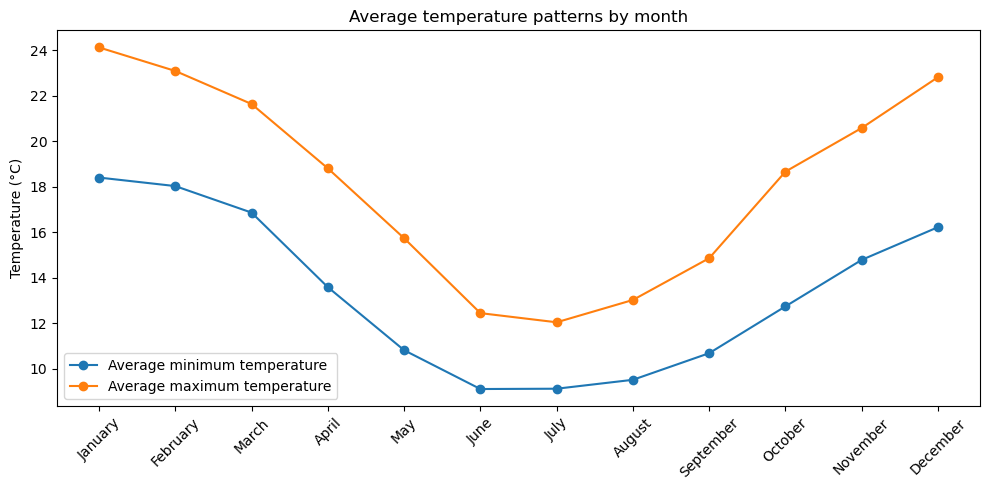

In [11]:
import matplotlib.pyplot as plt

month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
temp_plot = (
    weather_df.groupby("month_name", as_index=False)
    .agg(
        avg_min_temp=("Min temperature (°C)", "mean"),
        avg_max_temp=("Max temperature (°C)", "mean")
    )
)
temp_plot["month_name"] = pd.Categorical(temp_plot["month_name"], categories=month_order, ordered=True)
temp_plot = temp_plot.sort_values("month_name")

plt.figure(figsize=(10, 5))
plt.plot(temp_plot["month_name"], temp_plot["avg_min_temp"], marker="o", label="Average minimum temperature")
plt.plot(temp_plot["month_name"], temp_plot["avg_max_temp"], marker="o", label="Average maximum temperature")
plt.xticks(rotation=45)
plt.ylabel("Temperature (°C)")
plt.title("Average temperature patterns by month")
plt.legend()
plt.tight_layout()
plt.show()

Rainfall can be explored through both total monthly rainfall and the number of rainy days.

In [12]:
monthly_rain = (
    weather_df.groupby("month_name", as_index=False)
    .agg(
        total_rainfall_mm=("Total Rainfall (mm)", "sum"),
        rainy_days=("rain_day", "sum")
    )
)
monthly_rain["month_name"] = pd.Categorical(monthly_rain["month_name"], categories=month_order, ordered=True)
monthly_rain = monthly_rain.sort_values("month_name")
monthly_rain

,month_name,total_rainfall_mm,rainy_days
4,January,439.8,66
3,February,183.8,45
7,March,153.6,58
0,April,319.8,68
8,May,350.0,111
6,June,315.4,92
5,July,293.2,103
1,August,363.0,119
11,September,249.0,86
10,October,199.2,81


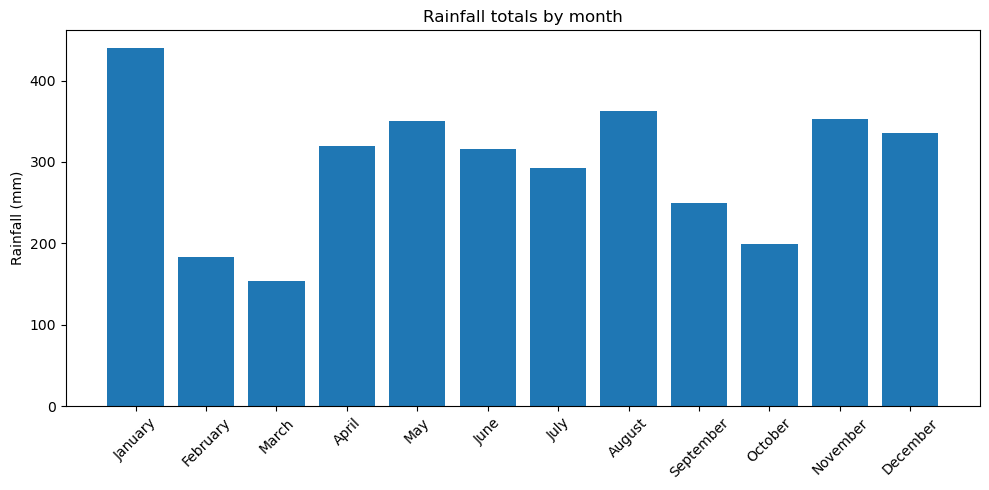

In [13]:
plt.figure(figsize=(10, 5))
plt.bar(monthly_rain["month_name"], monthly_rain["total_rainfall_mm"])
plt.xticks(rotation=45)
plt.ylabel("Rainfall (mm)")
plt.title("Rainfall totals by month")
plt.tight_layout()
plt.show()

Next, we have weather profile of each day, which is useful for checking whether the records are evenly distributed and whether any obvious weekday specific pattern appears in the observations.

In [14]:
weekday_profile = (
    weather_df.groupby("weekday", as_index=False)
    .agg(
        avg_min_temp=("Min temperature (°C)", "mean"),
        avg_max_temp=("Max temperature (°C)", "mean"),
        avg_rainfall=("Total Rainfall (mm)", "mean"),
        rain_day_rate=("rain_day", "mean")
    )
)

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
weekday_profile["weekday"] = pd.Categorical(weekday_profile["weekday"], categories=weekday_order, ordered=True)
weekday_profile = weekday_profile.sort_values("weekday")
weekday_profile

,weekday,avg_min_temp,avg_max_temp,avg_rainfall,rain_day_rate
1,Monday,12.883085,17.888060,1.017456,0.358209
5,Tuesday,13.204229,18.042786,1.179104,0.308458
6,Wednesday,13.504988,18.360349,1.252868,0.341646
4,Thursday,13.686849,18.388834,1.205955,0.359801
0,Friday,13.362779,18.123077,1.624938,0.362283
2,Saturday,13.145274,17.788557,1.389474,0.333333
3,Sunday,13.134988,17.843921,1.193017,0.337469


The most extreme weather days can be identified by ranking unusually hot, cold, wet, windy, or humid days. This would help highlight the certain observations in the dataset without needing a complex model.

In [15]:
extreme_weather_days = weather_df.assign(
    temp_range=weather_df["Max temperature (°C)"] - weather_df["Min temperature (°C)"]
).sort_values(
    by=["Max temperature (°C)", "Total Rainfall (mm)", "max gust speed(km/h)"],
    ascending=[False, False, False]
)

extreme_weather_days[
    ["Date", "Max temperature (°C)", "Min temperature (°C)", "Total Rainfall (mm)",
     "max gust speed(km/h)", "max wind speed (km/h)", "Max Humidity (%)",
     "Min Humidity (%)", "temp_range", "source_file"]
].head(15)

,Date,Max temperature (°C),Min temperature (°C),Total Rainfall (mm),max gust speed(km/h),max wind speed (km/h),Max Humidity (%),Min Humidity (%),temp_range,source_file
1814,2019-12-20,42.3,25.5,0.0,30.0,11.0,48.0,11.0,16.8,2015-2016 Historical
377,2016-01-13,41.7,17.0,0.2,52.0,32.0,95.0,12.0,24.7,2015-2016 Historical
352,2015-12-19,40.9,19.3,0.0,54.0,35.0,97.0,14.0,21.6,2015-2016 Historical
364,2015-12-31,39.3,21.9,0.0,35.0,24.0,67.0,10.0,17.4,2015-2016 Historical
418,2016-02-23,39.1,23.1,0.0,50.0,28.0,81.0,18.0,16.0,2015-2016 Historical
1113,2018-01-18,39.1,29.7,0.0,24.0,20.0,29.0,12.0,9.4,2015-2016 Historical
432,2016-03-08,38.6,20.0,0.6,37.0,20.0,92.0,20.0,18.6,2015-2016 Historical
1,2015-01-02,38.2,15.5,0.0,33.0,22.0,92.0,12.0,22.7,2015-2016 Historical
1484,2019-01-24,38.0,28.8,0.0,24.0,13.0,59.0,26.0,9.2,2015-2016 Historical
1436,2018-12-07,37.9,23.2,0.0,57.0,32.0,56.0,19.0,14.7,2015-2016 Historical


## Feature Engineering

In [16]:
weather_df["temperature_range"] = weather_df["Max temperature (°C)"] - weather_df["Min temperature (°C)"]
weather_df["humidity_range"] = weather_df["Max Humidity (%)"] - weather_df["Min Humidity (%)"]
weather_df["gust_to_wind_ratio"] = weather_df["max gust speed(km/h)"] / weather_df["max wind speed (km/h)"]
weather_df["wet_and_humid_day"] = np.where(
    (weather_df["rain_day"] == 1) & (weather_df["Max Humidity (%)"].fillna(0) >= 80),
    1,
    0
)

weather_df.head()

,Date,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),source_file,day,month,year,month_name,weekday,rain_day,temperature_range,humidity_range,gust_to_wind_ratio,wet_and_humid_day
0,2015-01-01,13.6,26.1,0.0,17:00,SSW,20.0,28.0,1015.9,92.0,35.0,2015-2016 Historical,1,1,2015,January,Thursday,0,12.5,57.0,1.400000,0
1,2015-01-02,15.5,38.2,0.0,13:30,NNW,22.0,33.0,1015.5,92.0,12.0,2015-2016 Historical,2,1,2015,January,Friday,0,22.7,80.0,1.500000,0
2,2015-01-03,21.8,37.7,0.0,14:30,N,37.0,57.0,1012.6,84.0,19.0,2015-2016 Historical,3,1,2015,January,Saturday,0,15.9,65.0,1.540541,0
3,2015-01-04,16.0,22.4,4.2,2:30,NNE,20.0,41.0,1020.4,93.0,33.0,2015-2016 Historical,4,1,2015,January,Sunday,1,6.4,60.0,2.050000,1
4,2015-01-05,15.1,21.5,0.0,18:00,SSW,22.0,41.0,1021.0,86.0,60.0,2015-2016 Historical,5,1,2015,January,Monday,0,6.4,26.0,1.863636,0


In [17]:
analysis_ready_weather = weather_df.copy()
analysis_ready_weather.to_csv(data_dir / "cleaned/cleaned_weather.csv", index=False)
analysis_ready_weather.head()

,Date,Min temperature (°C),Max temperature (°C),Total Rainfall (mm),Time of maximum gust,Direction of wind,max wind speed (km/h),max gust speed(km/h),max pressure (hPa),Max Humidity (%),Min Humidity (%),source_file,day,month,year,month_name,weekday,rain_day,temperature_range,humidity_range,gust_to_wind_ratio,wet_and_humid_day
0,2015-01-01,13.6,26.1,0.0,17:00,SSW,20.0,28.0,1015.9,92.0,35.0,2015-2016 Historical,1,1,2015,January,Thursday,0,12.5,57.0,1.400000,0
1,2015-01-02,15.5,38.2,0.0,13:30,NNW,22.0,33.0,1015.5,92.0,12.0,2015-2016 Historical,2,1,2015,January,Friday,0,22.7,80.0,1.500000,0
2,2015-01-03,21.8,37.7,0.0,14:30,N,37.0,57.0,1012.6,84.0,19.0,2015-2016 Historical,3,1,2015,January,Saturday,0,15.9,65.0,1.540541,0
3,2015-01-04,16.0,22.4,4.2,2:30,NNE,20.0,41.0,1020.4,93.0,33.0,2015-2016 Historical,4,1,2015,January,Sunday,1,6.4,60.0,2.050000,1
4,2015-01-05,15.1,21.5,0.0,18:00,SSW,22.0,41.0,1021.0,86.0,60.0,2015-2016 Historical,5,1,2015,January,Monday,0,6.4,26.0,1.863636,0
